# KMEANS CLUSTERING

KMeans is an unsupervised clustering algorithm that splits data into k groups by minimizing the distance between each point and its assigned centroid.

## 0. Environment setting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

from utils import define_feature_types
from preprocessing import drop_missing, impute, correct_skewness, cap_outliers, scale

DATA_PATH = "data/raw/"
RANDOM_STATE = 10

## 1. Data Loading

Three independent datasets are loaded: `incidents_master` (attack metadata), `financial_impact` (loss figures), and `market_impact` (stock market reaction).

Each will be treated both individually and in combinations to test whether richer feature sets produce more meaningful clusters.


### 1.1 Feature Definition — Incidents

Numerical features are auto-detected and then filtered to remove metadata columns that give no meaning for clustering. 

Two time-derived features are engineered: `discovery_delay_days` and `disclosure_delay_days`, capturing how quickly incidents were detected and disclosed.


In [2]:
df_incidents = pd.read_csv(DATA_PATH + "incidents_master.csv")

In [3]:
COLS_INC_IDENTITY = ["incident_id", "company_name", "stock_ticker", "notes", "created_at", "updated_at"]
COLS_INC_COMPANY  = ["company_revenue_usd", "country_hq", "industry_primary", "industry_secondary", "employee_count", "is_public_company"]
COLS_INC_TIME     = ["incident_date", "incident_date_estimated", "discovery_date", "disclosure_date"]
COLS_INC_ATTACK   = ["attack_vector_primary", "attack_vector_secondary", "attack_chain", "attributed_group", "attribution_confidence"]
COLS_INC_SEVERITY = ["data_compromised_records", "data_type", "systems_affected", "downtime_hours"]
COLS_INC_METADATA = ["data_source_primary", "data_source_secondary", "data_source_type", "confidence_tier", "quality_score", "quality_grade", "review_flag"]


In [4]:
COLS_INC_NUMERICAL, COLS_INC_CATEGORICAL = define_feature_types(df_incidents) # Numerical: ["company_revenue_usd", "confidence_tier", "employee_count", "data_compromised_records", "downtime_hours", "quality_score"]
COLS_INC_CATEGORICAL = ["industry_primary", "country_hq", "attack_vector_primary", "attack_chain", "attributed_group", "attribution_confidence", "is_public_company"] # Selection of features for result interpretation

date_cols = ["incident_date", "discovery_date", "disclosure_date"]
df_incidents[date_cols] = df_incidents[date_cols].apply(pd.to_datetime, errors="coerce") # .to_datetime: proper time data type
df_incidents["disclosure_delay_days"] = (df_incidents["disclosure_date"] - df_incidents["discovery_date"]).dt.days # .dt.days: datetime object to integer
df_incidents["discovery_delay_days"]  = (df_incidents["discovery_date"]  - df_incidents["incident_date"]).dt.days
COLS_INC_DELAY = ["disclosure_delay_days", "discovery_delay_days"] # Reaction and publishing times in days

COLS_INC_NUMERICAL  = list((set(COLS_INC_NUMERICAL) - set(COLS_INC_METADATA)) | set(COLS_INC_DELAY)) # ["company_revenue_usd", "disclosure_date", "discovery_date", "employee_count", "data_compromised_records", "downtime_hours"]

### 1.2 Feature Definition — Financial

Metadata columns are excluded as they describe the collection process rather than the incident itself. 

Only loss features are retained: direct losses, ransom amounts, recovery costs, legal fees, and regulatory fines.

In [5]:
df_financial = pd.read_csv(DATA_PATH + "financial_impact.csv")

In [6]:
COLS_FIN_IDENTITY = ["incident_id", "notes", "created_at", "updated_at"]
COLS_FIN_LOSSES   = ["direct_loss_usd", "recovery_cost_usd", "legal_fees_usd", "regulatory_fine_usd", "insurance_payout_usd", "total_loss_usd"]
COLS_FIN_RANSOM   = ["ransom_demanded_usd", "ransom_paid_usd"]
COLS_FIN_BOUNDS   = ["total_loss_lower_bound", "total_loss_upper_bound", "inflation_adjusted_usd"]
COLS_FIN_METADATA = ["direct_loss_method", "total_loss_method", "cpi_index_used", "ransom_source"]

In [7]:
COLS_FIN_NUMERICAL, COLS_FIN_CATEGORICAL = define_feature_types(df_financial)
COLS_FIN_CATEGORICAL = ["ransom_source", "direct_loss_method"]

COLS_FIN_NUMERICAL = list(set(COLS_FIN_NUMERICAL) - set(COLS_FIN_IDENTITY) - set(COLS_FIN_BOUNDS) - set(COLS_FIN_METADATA))

### 1.3 Feature Definition — Market

Statistical test columns are excluded, as they would introduce redundancy. 

Abnormal returns and volatility measures are kept as they quantify market-stock behavior and discrepancies.

In [8]:
df_market = pd.read_csv(DATA_PATH + "market_impact.csv")

In [9]:
COLS_MKT_IDENTITY = ["incident_id", "stock_ticker", "notes", "created_at", "updated_at"]
COLS_MKT_PRICE    = ["price_7d_before", "price_disclosure_day", "price_1d_after", "price_7d_after", "price_30d_after"]
COLS_MKT_VOLUME   = ["volume_avg_30d_baseline", "volume_disclosure_day", "volume_ratio_disclosure"]
COLS_MKT_RETURNS  = ["abnormal_return_1d", "abnormal_return_7d", "abnormal_return_30d", "car_neg1_to_pos1", "car_0_to_7", "car_0_to_30", "car_0_to_90"]
COLS_MKT_IMPACT   = ["sector_return_same_period", "market_cap_at_disclosure", "pre_incident_volatility_30d", "post_incident_volatility_30d", "days_to_price_recovery"]
COLS_MKT_STATS    = ["t_statistic_1d", "p_value_1d", "t_statistic_30d", "p_value_30d"]
COLS_MKT_METADATA = ["sector_index", "earnings_announcement_within_7d"]

COLS_MKT_NUMERICAL, COLS_MKT_CATEGORICAL = define_feature_types(df_market)
COLS_MKT_CATEGORICAL = ["sector_index", "earnings_announcement_within_7d"]

COLS_MKT_NUMERICAL = list(set(COLS_MKT_NUMERICAL) - set(COLS_MKT_IDENTITY) - set(COLS_MKT_METADATA) - set(COLS_MKT_STATS))

### 1.4. Dataset Construction

Dataset variants are built: the three source datasets individually, pairwise/triple combinations, and a price market variant (known to be the subset with the highest clustering stats from previous testing). 

Clustering will after be evaluated across different feature spaces to find the clearest structure.

In [10]:
COLS_INC_FIN_NUMERICAL     = COLS_INC_NUMERICAL + COLS_FIN_NUMERICAL
COLS_INC_MKT_NUMERICAL     = COLS_INC_NUMERICAL + COLS_MKT_NUMERICAL
COLS_INC_FIN_MKT_NUMERICAL = COLS_INC_NUMERICAL + COLS_FIN_NUMERICAL + COLS_MKT_NUMERICAL

COLS_INC_FIN_CATEGORICAL     = COLS_INC_CATEGORICAL + COLS_FIN_CATEGORICAL
COLS_INC_MKT_CATEGORICAL     = COLS_INC_CATEGORICAL + COLS_MKT_CATEGORICAL
COLS_INC_FIN_MKT_CATEGORICAL = COLS_INC_CATEGORICAL + COLS_FIN_CATEGORICAL + COLS_MKT_CATEGORICAL

df_inc_fin  = df_incidents.merge(df_financial, on="incident_id", how="inner")[COLS_INC_FIN_NUMERICAL + COLS_INC_FIN_CATEGORICAL]
df_inc_mkt  = df_incidents.merge(df_market,    on="incident_id", how="inner")[COLS_INC_MKT_NUMERICAL + COLS_INC_MKT_CATEGORICAL]
df_inc_fin_mkt = df_incidents.merge(df_financial, on="incident_id", how="inner").merge(df_market, on="incident_id", how="inner")[COLS_INC_FIN_MKT_NUMERICAL + COLS_INC_FIN_MKT_CATEGORICAL]

datasets = {
    "inc":         (df_incidents,   COLS_INC_NUMERICAL,         COLS_INC_CATEGORICAL),
    "fin":         (df_financial,   COLS_FIN_NUMERICAL,         COLS_FIN_CATEGORICAL),
    "mkt":         (df_market,      COLS_MKT_NUMERICAL,         COLS_MKT_CATEGORICAL),
    "inc_fin":     (df_inc_fin,     COLS_INC_FIN_NUMERICAL,     COLS_INC_FIN_CATEGORICAL),
    "inc_mkt":     (df_inc_mkt,     COLS_INC_MKT_NUMERICAL,     COLS_INC_MKT_CATEGORICAL),
    "inc_fin_mkt": (df_inc_fin_mkt, COLS_INC_FIN_MKT_NUMERICAL, COLS_INC_FIN_MKT_CATEGORICAL),
    "mkt_price":   (df_market[COLS_MKT_PRICE],   COLS_MKT_PRICE,   COLS_MKT_CATEGORICAL)}

## 2. Preprocessing
KMeans is based on euclidean distance and is sensitive to scale, so each dataset is preprocessed independently through a fixed pipeline to obtain clean datasets with comparable data points: 
- Columns and rows with an amount of missing values over a certain threshold are dropped.
- Remaining NaN values are imputed 
- Skewed distributions are corrected.
- Outliers are capped at outer fences.
- Features are standardized. 

In [11]:
for name, (df, num_cols, cat_cols) in datasets.items():
    df, num_cols = drop_missing(df, num_cols)
    df = impute(df, num_cols)
    df = correct_skewness(df, num_cols)
    df = cap_outliers(df, num_cols)
    df = scale(df, num_cols)
    datasets[name] = (df, num_cols, cat_cols)

*Preprocessing functions are imported and executed concisely to keep the pipeline clear and the focus of this notebook on PCA and KMeans clustering.*

*Their implementation and step-by-step effects are documented in `preprocessing_implementation.ipynb`.*

## 3. Dimensionality Reduction - PCA

PCA is applied to each dataset to create a new set of components by extracting meaning from the features.

This process reduces redundancies and compresses correlated features (to 2, 3, 5 principal components and 95% variance preservation).

In [12]:
def reduce_pca(df, numerical_cols, n_components):
    pca = PCA(n_components=n_components)
    df_pca = pca.fit_transform(df[numerical_cols])
    return df_pca, pca

In [13]:
def plot_pca_variance(pca_results):
    colors = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    max_components = max(len(pca.explained_variance_ratio_) for pca in pca_results.values())
    for (name, pca), color in zip(pca_results.items(), colors):
        explained = pca.explained_variance_ratio_
        cumulative = np.cumsum(explained)
        x = list(range(1, len(explained) + 1))
        axes[0].plot(x, explained,  "o-", color=color, alpha=0.5)
        axes[0].text(x[-1] + 0.15, explained[-1],  name, va="center", fontsize=7, color=color)
        axes[1].plot(x, cumulative, "o-", color=color, alpha=0.5)
        axes[1].text(x[-1] + 0.15, cumulative[-1], name, va="center", fontsize=7, color=color)
    axes[1].axhline(y=0.90, color="orange", linestyle=":", linewidth=1.2, alpha=0.7)
    axes[1].axhline(y=0.95, color="#DD4444", linestyle=":", linewidth=1.2, alpha=0.7)
    axes[1].text(0.5, 0.91, "90%", fontsize=8, color="orange",  transform=axes[1].get_yaxis_transform())
    axes[1].text(0.5, 0.96, "95%", fontsize=8, color="#DD4444", transform=axes[1].get_yaxis_transform())
    for ax, title, ylabel in zip(axes, ["Explained Variance per Component", "Cumulative Variance Retained"], ["Variance explained", "Cumulative variance"]):
        ax.set_xlim(right=max_components + 2.5)
        ax.set_title(title, fontsize=13, fontweight="bold", pad=15)
        ax.set_xlabel("Component", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()

def print_pca_loadings(pca_results, datasets):
    for name, pca in pca_results.items():
        original = name.rsplit("_pca", 1)[0]
        if original not in datasets:
            continue
        entry = datasets[original]
        num_cols = entry[1]
        loadings = pd.DataFrame(pca.components_.T, index=num_cols, columns=[f"PC{i+1}" for i in range(pca.n_components_)])
        summary = {}
        for col in loadings.columns:
            top3 = loadings[col].abs().nlargest(3)
            summary[col] = [f"{feat} ({val:.2f})" for feat, val in top3.items()]
        display(pd.DataFrame(summary, index=["#1", "#2", "#3"]))

def add_pca_datasets(datasets, n_components):
    pca_results  = {}
    pca_datasets = {}
    for name, entry in datasets.items():
        df, num_cols, cat_cols = entry[0], entry[1], entry[2]
        if isinstance(df, np.ndarray) or not num_cols:
            continue
        available_cat = [c for c in cat_cols if c in df.columns] if cat_cols else []
        df_cat = df[available_cat].reset_index(drop=True) if available_cat else None
        for n in n_components:
            if n >= 1 and n >= len(num_cols):
                continue
            df_pca, pca = reduce_pca(df, num_cols, n)
            pca_num_cols = [f"PC{i+1}" for i in range(df_pca.shape[1])]
            key = f"{name}_pca{int(n*100) if n < 1 else n}"
            pca_datasets[key] = (df_pca, pca_num_cols, available_cat, df_cat)
            pca_results[key] = pca
    datasets.update(pca_datasets)
    return datasets, pca_results

def print_pca_info(pca_results):
    for name, pca in pca_results.items():
        n_components  = pca.n_components_
        n_original    = pca.n_features_in_
        variance      = pca.explained_variance_ratio_.sum()
        reduction     = (1 - n_components / n_original) * 100
        cumulative    = np.cumsum(pca.explained_variance_ratio_)
        thresholds    = [0.50, 0.70, 0.80, 0.90, 0.95]
        print(f"  Components selected : {n_components} (from {n_original} original features)")
        print(f"  Dimensionality reduction: {reduction:.1f}%")
        print(f"  Variance retained   : {variance:.3f}")
        print(f"\n  Cumulative variance explained:")
        for t in thresholds:
            n = next((i+1 for i, v in enumerate(cumulative) if v >= t), n_components)
            print(f"    {int(t*100)}% variance - {n} components")

### 4.1 Variance Analysis & Loadings

The explained variance plot shows how much information each principal component captures. 

The cumulative plot explains about how many components are needed to preserve a certain percentage of the variance. 

Loadings reveal which original features have greater weights and at what proportion for each principal component (useful for interpreting the clusters' domain).

In [14]:
N_COMPONENTS = [2,3,5,0.95]
datasets, pca_results = add_pca_datasets(datasets, n_components=N_COMPONENTS)

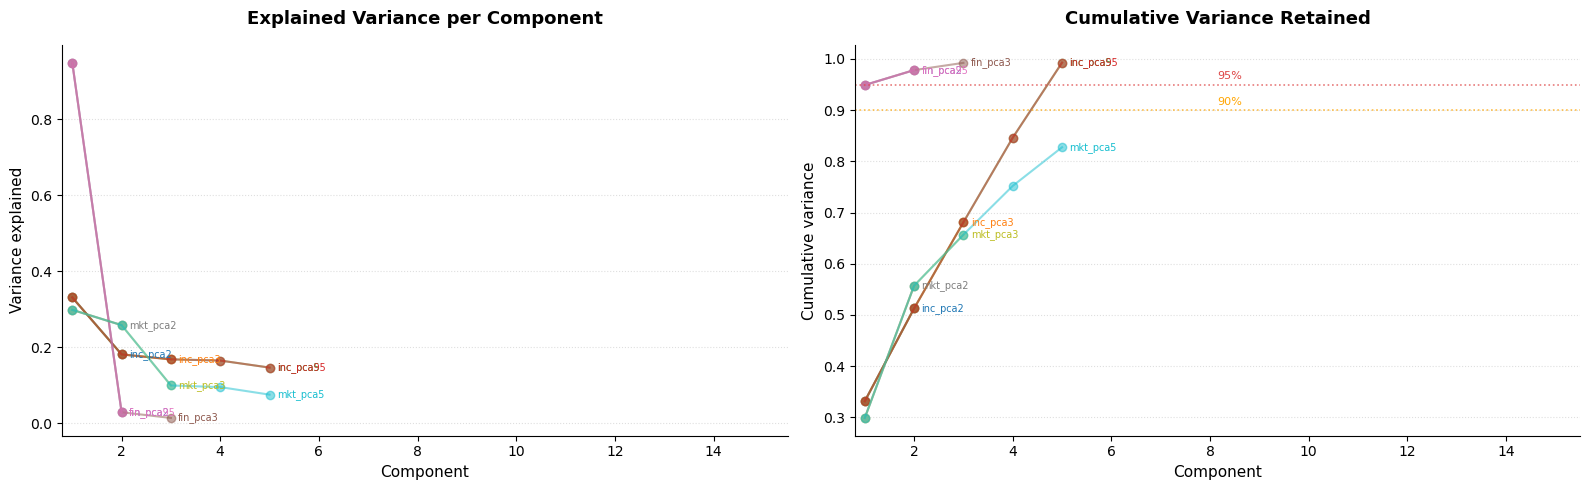

In [15]:
plot_pca_variance(pca_results)

For most of the cases (plotted and not), more than half the variance is contained in just 3 components.

This suggests a few strong underlying patterns drive most of the variation.

In [16]:
chosen_results = {"inc_fin_mkt_pca95": pca_results["inc_fin_mkt_pca95"]}
print_pca_info(chosen_results)

  Components selected : 13 (from 31 original features)
  Dimensionality reduction: 58.1%
  Variance retained   : 0.955

  Cumulative variance explained:
    50% variance - 3 components
    70% variance - 5 components
    80% variance - 8 components
    90% variance - 11 components
    95% variance - 13 components


In [17]:
print_pca_loadings(chosen_results, datasets)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
#1,price_7d_before (0.32),abnormal_return_7d (0.38),total_loss_usd (0.39),volume_disclosure_day (0.67),pre_incident_volatility_30d (0.70),days_to_price_recovery (0.54),volume_ratio_disclosure (0.48),discovery_delay_days (0.61),downtime_hours (0.61),data_compromised_records (0.61),sector_return_same_period (0.83),disclosure_delay_days (0.56),days_to_price_recovery (0.72)
#2,price_disclosure_day (0.32),car_0_to_7 (0.38),direct_loss_usd (0.39),volume_avg_30d_baseline (0.64),post_incident_volatility_30d (0.70),abnormal_return_1d (0.33),disclosure_delay_days (0.48),disclosure_delay_days (0.55),volume_ratio_disclosure (0.51),discovery_delay_days (0.59),volume_ratio_disclosure (0.37),downtime_hours (0.51),car_0_to_90 (0.37)
#3,price_30d_after (0.32),car_0_to_30 (0.38),recovery_cost_usd (0.39),volume_ratio_disclosure (0.20),discovery_delay_days (0.07),car_neg1_to_pos1 (0.32),sector_return_same_period (0.47),data_compromised_records (0.49),data_compromised_records (0.40),downtime_hours (0.48),data_compromised_records (0.23),volume_ratio_disclosure (0.44),car_neg1_to_pos1 (0.33)


*`inc_fin_mkt_pca2` is selected as an example for reasons that will be justified later.*

The loadings reflect the weight of each feature on each component, so it is clear that, in order, the components mainly explain about:
- **PC1**  - Stock price level: absolute price at different times relative to the incident (representing the companies' size and valuation).
- **PC2**  - Market reaction: abnormal returns (measuring how much the stock deviated from expected performance).
- **PC3**  - Financial loss: different magnitudes of economical recession.
- **PC4**  - Trading volume spike: how much investor activity surged when incident was made public, relative to baseline (a measure of market attention).
- **PC5**  - Volatility profile: pre and post-incident price instability stats.
- **etc.** - Each remaining component isolates a narrower, more specific signal: recovery and disclosure times, real damage indicators (downtime hours, records compromised) and so on.

PC1 and PC2 together capture most of the variance, meaning the clustering is primarily structured around **how large the company is** and **how strongly the market reacted** to the incident.

## 4. KMeans Clustering

KMeans is fitted for different values of k across all dataset variants. 

The elbow and silhouette plots are used together to select candidates: the elbow identifies where inertia stops decreasing sharply, while silhouette confirms that clusters are well-separated. 

The top dataset variations by silhouette score are chosen for posterior quality evaluation and visualization.

In [18]:
def get_data(df, num_cols):
    return df if isinstance(df, np.ndarray) else df[num_cols]

def compute_kmeans_results(datasets, k_range=range(2, 11)):
    results = {}
    for name, entry in datasets.items():
        df, num_cols, cat_cols = entry[0], entry[1], entry[2]
        if len(entry) > 3:
            df_cat        = entry[3]
            available_cat = cat_cols
        else:
            if isinstance(df, np.ndarray) or not cat_cols:
                df_cat        = None
                available_cat = []
            else:
                available_cat = [c for c in cat_cols if c in df.columns]
                df_cat        = df[available_cat].reset_index(drop=True) if available_cat else None
        data = get_data(df, num_cols)
        results[name] = {}
        for k in k_range:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
            labels = model.fit_predict(data)
            results[name][k] = {"model": model, "labels": labels, "inertia": model.inertia_, "silhouette": silhouette_score(data, labels), "data": data,
                                "num_cols": num_cols, "cat_cols": available_cat, "df_cat": df_cat, "df": df}
    return results

def kmeans_evaluation_table(results):
    rows = []
    for dataset, ks in results.items():
        for k, r in ks.items():
            rows.append({"dataset": dataset, "k": k, "inertia": r["inertia"], "silhouette": r["silhouette"]})
    return pd.DataFrame(rows)

def select_top_datasets(df_eval, top_per_dataset=2, total=10):
    df_eval["base_dataset"] = df_eval["dataset"].str.replace(r"_pca\d+", "", regex=True)
    top = (df_eval.groupby("base_dataset").apply(lambda x: x.nlargest(top_per_dataset, "silhouette"), include_groups=False).reset_index(drop=True))
    return top.sort_values("silhouette", ascending=False).head(total)

def fit_final_models(top, results):
    models = {}
    for _, row in top.iterrows():
        models[row["dataset"]] = results[row["dataset"]][int(row["k"])]
    return models

def evaluate_cluster_quality(final_models):
    rows = []
    for name, d in final_models.items():
        kmeans, labels, data = d["model"], d["labels"], d["data"]
        centroids      = kmeans.cluster_centers_
        centroid_dists = [np.linalg.norm(centroids[i] - centroids[j]) for i in range(len(centroids)) for j in range(i + 1, len(centroids))]
        rows.append({"model": name, "k": len(np.unique(labels)), "silhouette": round(silhouette_score(data, labels), 4),
                     "davies_bouldin": round(davies_bouldin_score(data, labels), 4), "calinski_harabasz": round(calinski_harabasz_score(data, labels), 4),
                     "avg_dist_centroid": round(np.mean(np.min(kmeans.transform(data), axis=1)), 4), "avg_centroid_dist": round(np.mean(centroid_dists), 4),
                     "cluster_sizes": pd.Series(labels).value_counts().sort_index().to_dict()})
    return pd.DataFrame(rows)

def plot_elbow_silhouette(results):
    colors = plt.cm.tab10.colors
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    for (name, ks), color in zip(results.items(), colors):
        k_vals   = sorted(ks.keys())
        inertias = [ks[k]["inertia"]    for k in k_vals]
        scores   = [ks[k]["silhouette"] for k in k_vals]
        axes[0].plot(k_vals, inertias, "o-", color=color, alpha=0.5, linewidth=1, markersize=3)
        axes[0].text(k_vals[-1] + 0.15, inertias[-1], f"{name}", va="center", fontsize=6, color=color)
        axes[1].plot(k_vals, scores, "o-", color=color, alpha=0.5, linewidth=1, markersize=3)
        axes[1].text(k_vals[-1] + 0.15, scores[-1], f"{name}", va="center", fontsize=6, color=color)
    axes[0].set_xlim(right=max(k_vals) + 2.5)
    axes[0].set_title("Elbow (Inertia)", fontsize=9)
    axes[0].set_xlabel("k", fontsize=8)
    axes[0].tick_params(labelsize=7)
    axes[0].spines[["top", "right"]].set_visible(False)
    axes[1].set_xlim(right=max(k_vals) + 2.5)
    axes[1].set_title("Silhouette Score", fontsize=9)
    axes[1].set_xlabel("k", fontsize=8)
    axes[1].tick_params(labelsize=7)
    axes[1].spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_pca_2d(final_models):
    plottable = {n: d for n, d in final_models.items() if np.array(d["data"]).shape[1] >= 2}
    if not plottable:
        return
    fig, axes = plt.subplots(1, len(plottable), figsize=(6 * len(plottable), 5))
    if len(plottable) == 1:
        axes = [axes]
    for ax, (name, d) in zip(axes, plottable.items()):
        data = np.array(d["data"])
        pca = PCA(n_components=2)
        pca_2d = pca.fit_transform(data) if data.shape[1] > 2 else data[:, :2]
        centroids_2d = pca.transform(d["model"].cluster_centers_) if data.shape[1] > 2 else d["model"].cluster_centers_[:, :2]
        ax.scatter(pca_2d[:, 0], pca_2d[:, 1], c=d["labels"], cmap="tab20b", alpha=0.4)
        ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c="black", marker="X", s=200, zorder=5)
        ax.set_title(name)
        ax.grid(True, linestyle=":", alpha=0.2)
        ax.spines[["top", "right"]].set_visible(False)
    plt.suptitle("PCA 2D")
    plt.tight_layout()
    plt.show()

def plot_tsne(final_models):
    plottable = {n: d for n, d in final_models.items() if np.array(d["data"]).shape[1] >= 2}
    if not plottable:
        return
    fig, axes = plt.subplots(1, len(plottable), figsize=(6 * len(plottable), 5))
    if len(plottable) == 1:
        axes = [axes]
    for ax, (name, d) in zip(axes, plottable.items()):
        data= np.array(d["data"])
        tsne= TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
        tsne_2d = tsne.fit_transform(data)
        centroid_indices = [np.linalg.norm(data - c, axis=1).argmin() for c in d["model"].cluster_centers_]
        centroid_points  = tsne_2d[centroid_indices]
        ax.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=d["labels"], cmap="tab20b", alpha=0.4)
        ax.scatter(centroid_points[:, 0], centroid_points[:, 1], c="black", marker="X", s=200, zorder=5)
        ax.set_title(name)
        ax.grid(True, linestyle=":", alpha=0.2)
        ax.spines[["top", "right"]].set_visible(False)
    plt.suptitle("t-SNE Projections")
    plt.tight_layout()
    plt.show()

def profile_clusters_categorical(final_models):
    for name, d in final_models.items():
        labels = d["labels"]
        cat_cols = d["cat_cols"]
        df_cat = d["df_cat"]
        if not cat_cols or df_cat is None:
            continue
        df_profile = df_cat.copy().reset_index(drop=True)
        df_profile["cluster"] = labels
        rows = []
        for cluster_id in sorted(df_profile["cluster"].unique()):
            row = {"cluster": cluster_id}
            subset = df_profile[df_profile["cluster"] == cluster_id]
            for col in cat_cols:
                top_val = subset[col].value_counts(normalize=True)
                row[col] = f"{top_val.index[0]} ({top_val.iloc[0]*100:.0f}%)"
            rows.append(row)
        display(pd.DataFrame(rows).set_index("cluster"))
        
def profile_clusters_numerical(results, dataset_name, k, df_orig, num_cols):
    d = results[dataset_name][k]
    df = df_orig.copy().reset_index(drop=True)
    df["cluster"] = d["labels"]
    display(df.groupby("cluster")[num_cols].mean().round(2))

### 5.1. Clustering Analysis - First Evaluation

The most promising candidates are chosen and displayed for contrasting.

#### i) Fit


In [19]:
# Fit KMeans model for a specific range of k across all dataset variants and return an evaluation
results = compute_kmeans_results(datasets)

#### ii) K Value Selection

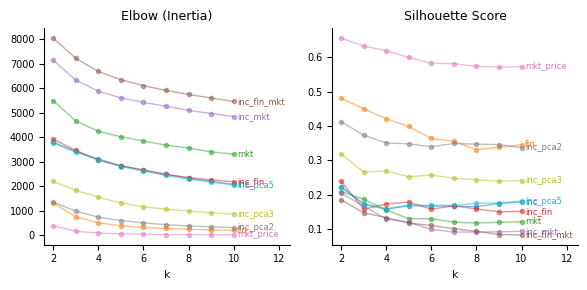

In [20]:
# Plot elbow and silhouette graphs to identify candidates
plot_elbow_silhouette(results)

#### iii) Candidate Datasets

In [21]:
# Build evaluation table and select top combinations by silhouette score
df_eval = kmeans_evaluation_table(results)
top10 = select_top_datasets(df_eval)

# Retrieve final models for the top combinations from results
final_models = fit_final_models(top10, results)

#### iv) Clustering Visualization

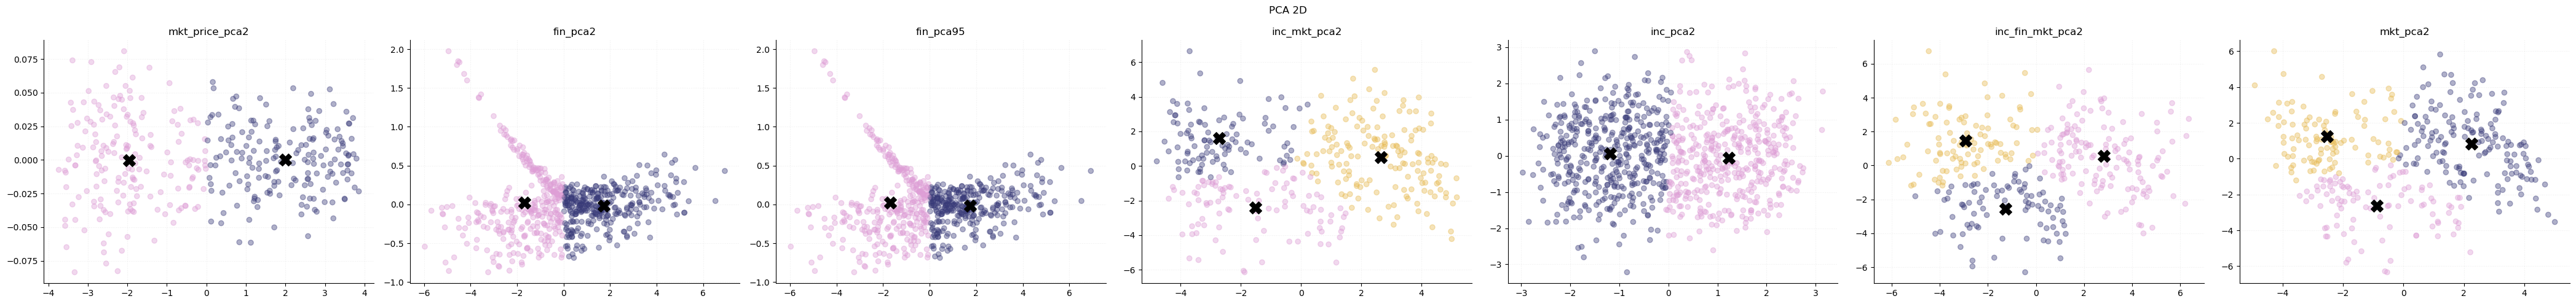

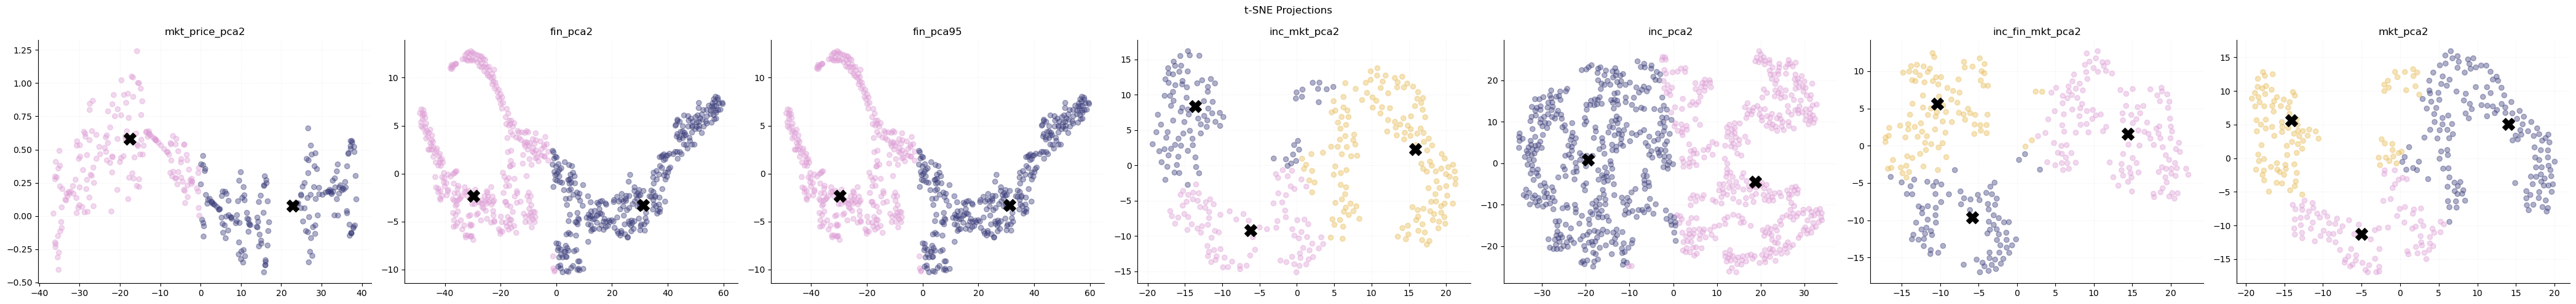

In [22]:
# Visual inspection of cluster structure in 2D
plot_pca_2d(final_models)
plot_tsne(final_models)

*PCA is a linear projection and may not separate clusters that are non-linearly structured, so t-SNE is included as a complementary view to reveal separation that PCA might miss.*

#### v) Clustering Evaluation

In [23]:
# Internal quality metrics for all final models
quality = evaluate_cluster_quality(final_models)
display(quality)

,model,k,silhouette,davies_bouldin,calinski_harabasz,avg_dist_centroid,avg_centroid_dist,cluster_sizes
0,mkt_price_pca95,2,0.6568,0.4481,1274.6884,0.8859,3.9535,"{0: 178, 1: 180}"
1,mkt_price_pca2,2,0.6563,0.4488,1273.6720,0.8873,3.9535,"{0: 178, 1: 180}"
2,fin_pca2,2,0.5044,0.6790,949.1099,1.1622,3.4228,"{0: 316, 1: 322}"
3,fin_pca95,2,0.5044,0.6790,949.1099,1.1622,3.4228,"{0: 316, 1: 322}"
4,inc_mkt_pca2,3,0.4000,0.8626,307.5237,1.9696,4.9155,"{0: 99, 1: 159, 2: 100}"
5,inc_pca2,2,0.4132,0.9517,754.8376,1.1498,2.4166,"{0: 426, 1: 412}"
6,inc_fin_mkt_pca2,3,0.4089,0.8537,291.4741,2.0189,5.1004,"{0: 88, 1: 99, 2: 142}"
7,mkt_pca2,3,0.3986,0.8266,290.5033,1.8421,4.5548,"{0: 155, 1: 104, 2: 99}"


*Clustering is evaluated using internal metrics only: silhouette score (separation quality), Davies-Bouldin index (compactness ratio), and Calinski-Harabasz score (between vs within cluster dispersion). External metrics such as purity or Rand Index are not applicable as the datasets have no ground truth labels.*

From visual inspection of the plots and study of the quality numbers:
- **Market price features produce the strongest clustering** (*best silhouette is 0.66*) - separating companies by financial scale.
- **Financial loss features cluster well** (*best silhouette is 0.50*) - binary split between high and low impact incidents.
- **Incident features reduces cluster quality** - richer feature space introduces noise that dilutes meaning.
- **k=2 dominates** - the best models cluster in pairs, followed by k=3.
- **The primary clustering signal is company size not attack characteristics** - incident metadata adds interpretability but not geometric separation.
- Silhouette score is the main indicator, and the rest of indicators reinforce it consistently.

### 5.1. Clustering Analysis - Second Evaluation

A single dataset is chosen for a final, deeper evaluation.

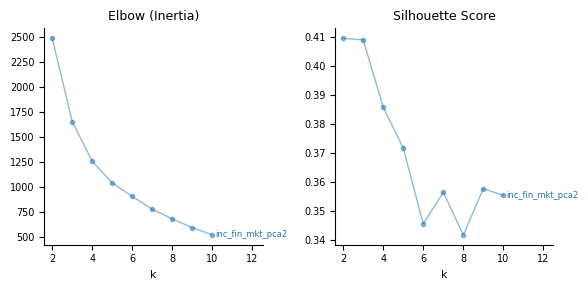

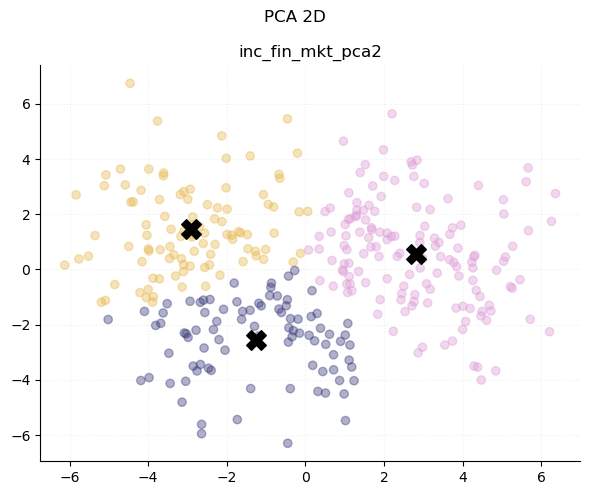

In [24]:
chosen_dataset = {"inc_fin_mkt_pca2": datasets["inc_fin_mkt_pca2"]}

results_chosen = compute_kmeans_results(chosen_dataset)
plot_elbow_silhouette(results_chosen)
df_eval_chosen = kmeans_evaluation_table(results_chosen)
top = select_top_datasets(df_eval_chosen)
final_models_chosen = fit_final_models(top, results_chosen)

plot_pca_2d(final_models_chosen)

`inc_fin_mkt_pca2` is selected for the final analysis as it combines all three data sources, offering the richest feature space for interpretation, with not the best but good enough stats. 

While it scores lower on silhouette than market-only datasets, it allows cluster profiles to be read across financial/market/incident dimensions, so it trades cluster density for interpretability.

In [25]:
quality = evaluate_cluster_quality(final_models_chosen)
display(quality)

profile_clusters_numerical(results_chosen, "inc_fin_mkt_pca2", 3, df_inc_fin_mkt, COLS_INC_FIN_MKT_NUMERICAL)

profile_clusters_categorical(final_models_chosen)


,model,k,silhouette,davies_bouldin,calinski_harabasz,avg_dist_centroid,avg_centroid_dist,cluster_sizes
0,inc_fin_mkt_pca2,3,0.4089,0.8537,291.4741,2.0189,5.1004,"{0: 88, 1: 99, 2: 142}"


,discovery_delay_days,company_revenue_usd,employee_count,data_compromised_records,disclosure_delay_days,downtime_hours,ransom_paid_usd,ransom_demanded_usd,total_loss_usd,regulatory_fine_usd,...,abnormal_return_7d,price_7d_after,abnormal_return_30d,price_1d_after,volume_ratio_disclosure,car_0_to_90,volume_disclosure_day,pre_incident_volatility_30d,car_0_to_7,volume_avg_30d_baseline
cluster,,,,,,,,,,,,,,,,,,,,,
0,31.65,3.261090e+09,14624.25,8732106.18,35.39,101.81,4048200.92,10026595.32,3.589545e+07,2861703.57,...,-0.06,27.02,-0.04,27.20,2.75,-0.03,5289173.84,0.02,-0.06,1959461.72
1,36.81,1.476204e+09,10179.54,1370012.19,31.76,124.22,4041847.63,9625662.06,2.493716e+07,4433406.70,...,-0.02,17.37,-0.00,17.32,2.66,-0.00,14230338.75,0.02,-0.02,5203437.25
2,39.23,3.286388e+10,163361.82,1551900.46,30.11,83.82,1857268.56,4591996.38,1.564752e+08,1418535.37,...,-0.03,246.60,-0.01,245.09,2.81,-0.01,9765953.51,0.02,-0.03,3428641.26


,industry_primary,country_hq,attack_vector_primary,attack_chain,attributed_group,attribution_confidence,is_public_company,direct_loss_method,sector_index,earnings_announcement_within_7d
cluster,,,,,,,,,,
0,51 (16%),US (40%),ransomware (35%),Phishing email with weaponized attachment → cr...,RansomHub (11%),suspected (38%),True (100%),estimated (52%),S&P 500 Industrials (17%),False (93%)
1,62 (18%),US (35%),phishing (29%),Spear-phishing campaign targeting finance team...,Sandworm (8%),suspected (33%),True (100%),estimated (45%),S&P 500 Consumer Discretionary (18%),False (87%)
2,51 (22%),US (35%),ransomware (27%),Phishing email with weaponized attachment → cr...,Hunters_International (8%),probable (41%),True (100%),estimated (44%),S&P 500 Information Technology (22%),False (87%)


#### Cluster Interpretation

Knowing the primary axis of cluster separation is **company size**, followed by **market reaction**, three distinct company archetypes emerge:

**Cluster 0** (yellow) — Mid-size, severe operational damage
- $3.3 billion revenue, 14000 employees, highest data breach volume (8.7 million records), highest ransom demanded ($10 million), slowest stock recovery (154 days), strongest negative market reaction.

**Cluster 1** (blue) — Mid/Small companies, low impact incidents
- $1.5 billion revenue, 10000 employees, longest downtime (124 hours), lowest overall losses, highest trading volume on disclosure day (14.2 million) despite smallest size, near-flat market reaction (returns around -0.02).

**Cluster 2** (pink) — Large enterprises, scale dominates
- $32.9 billion revenue, 163000 employees, highest absolute losses ($156 million in total), moderate market reaction, much higher stock prices ($254 vs $18–29).

Regarding categorical attributes, no strong signal emerges:
- Common ground: this reflects a sampling bias in the dataset (predominantly US-based public companies) rather than a genuine cluster structure in the categorical dimensions.
- Minor tendencies: **Cluster 0** leans towards `ransomware` attacks and `Industrial` sector, **Cluster 1** towards `phishing` and `Retail and Leisure`, and **Cluster 2** also towards `ransomware` but `IT` sector, with the highest confidence on who the authors are.